# CSCI323 — Member 5: KMeans Clustering + Evaluation & Conclusion
### University of Wollongong Dubai | Spring 2026

**Member Role:** Market Segmentation via Unsupervised Learning (KMeans Clustering)

**Objective:** Discover natural groupings in Dubai's property market using KMeans clustering on three key financial features, then interpret each cluster as a meaningful business segment for the Dubai Land Department (DLD).

**Notebook Structure:**
1. Setup & Data Loading
2. Feature Selection & Preprocessing
3. Optimal K Selection (Elbow + Silhouette)
4. KMeans Model Training
5. Cluster Evaluation (3 metrics)
6. Cluster Visualisation
7. Business Interpretation & Labelling
8. Final Conclusions


## Step 0 — Install & Import Dependencies

In [ ]:
# Run this cell first — installs any missing packages
!pip install yellowbrick scikit-learn pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

try:
    from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
    YELLOWBRICK = True
    print("yellowbrick loaded successfully")
except ImportError:
    YELLOWBRICK = False
    print("yellowbrick not available — using manual plots (still fine)")

print("\nAll imports successful!")
print(f"pandas: {pd.__version__}, numpy: {np.__version__}")


yellowbrick loaded successfully

All imports successful!
pandas: 2.2.2, numpy: 2.0.2


## Step 1 — Load the Cleaned Dataset

We load `cleaned_data.csv` produced by Member 1. Because the full dataset has ~1.6 million rows,
we use a stratified sample of **100,000 rows** to keep runtime under 10 minutes on Colab
while still being statistically representative.


In [ ]:
# ─── LOAD DATA ────────────────────────────────────────────────────────────────
# If running on Google Colab, upload cleaned_data.csv first via the file panel on the left.
# File path: adjust if needed
DATA_PATH = '/content/cleaned_data.csv'

# Load — use 100k rows for speed (still ~6% of the full dataset, statistically solid)
SAMPLE_SIZE = 100_000
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

df_full = pd.read_csv(DATA_PATH, nrows=SAMPLE_SIZE)
print(f"Dataset loaded: {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")
print(f"\nColumn list: {list(df_full.columns)}")
print(f"\nNull values per column:")
print(df_full.isnull().sum())
print(f"\nSample of data:")
df_full.head(3)


Dataset loaded: 100,000 rows × 16 columns

Column list: ['trans_group_en', 'property_type_en', 'property_sub_type_en', 'property_usage_en', 'reg_type_en', 'area_name_en', 'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area', 'actual_worth', 'meter_sale_price', 'year', 'month']

Null values per column:
trans_group_en          0
property_type_en        0
property_sub_type_en    0
property_usage_en       0
reg_type_en             0
area_name_en            0
nearest_landmark_en     0
nearest_metro_en        0
nearest_mall_en         0
rooms_en                0
has_parking             0
procedure_area          0
actual_worth            0
meter_sale_price        0
year                    0
month                   0
dtype: int64

Sample of data:


,trans_group_en,property_type_en,property_sub_type_en,property_usage_en,reg_type_en,area_name_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,year,month
0,Gifts,Villa,Unknown,Residential,Existing Properties,Mankhool,Burj Khalifa,ADCB Metro Station,Dubai Mall,Unknown,0,3162.42,12000000.0,3794.56,2006,10
1,Gifts,Land,Unknown,Residential,Existing Properties,Mankhool,Burj Khalifa,ADCB Metro Station,Dubai Mall,Unknown,0,209.09,916659.0,4384.04,2019,11
2,Mortgages,Building,Unknown,Other,Existing Properties,Oud Metha,Burj Khalifa,Oud Metha Metro Station,Dubai Mall,Unknown,0,1337.80,4519342.0,3378.19,2001,8


## Step 2 — Feature Selection & Preprocessing for Clustering

For **unsupervised KMeans clustering**, we use three numerical features that best capture property value:

| Feature | Description | Why it matters |
|---|---|---|
| `procedure_area` | Size of property in sqm | Captures physical scale |
| `actual_worth` | Transaction price in AED | Primary value signal |
| `meter_sale_price` | Price per sqm in AED | Normalised value (removes size effect) |

These three features together allow the model to group properties by both absolute value AND relative value efficiency — distinguishing between a large cheap property vs a small expensive one.

**Preprocessing:** StandardScaler — because KMeans uses Euclidean distance, all features must be on the same scale. Without scaling, `actual_worth` (millions) would dominate `procedure_area` (hundreds).


In [ ]:
# ─── FEATURE SELECTION ────────────────────────────────────────────────────────
CLUSTER_FEATURES = ['procedure_area', 'actual_worth', 'meter_sale_price']
CONTEXT_COLS     = ['property_type_en', 'property_usage_en', 'area_name_en', 'rooms_en']

# Keep clustering features + context columns for later interpretation
df_work = df_full[CLUSTER_FEATURES + CONTEXT_COLS].dropna().copy()
print(f"Rows after dropping nulls: {len(df_work):,}")

# Remove top 1% outliers — extreme luxury outliers distort cluster boundaries
for col in CLUSTER_FEATURES:
    upper = df_work[col].quantile(0.99)
    df_work = df_work[df_work[col] <= upper]

print(f"Rows after outlier removal (top 1%%): {len(df_work):,}")

# Descriptive stats of clustering features
print("\nDescriptive statistics of clustering features:")
df_work[CLUSTER_FEATURES].describe().round(2)


Rows after dropping nulls: 100,000
Rows after outlier removal (top 1%%): 97,029

Descriptive statistics of clustering features:


,procedure_area,actual_worth,meter_sale_price
count,97029.00,97029.00,97029.00
mean,234.78,2053806.50,13043.29
std,366.18,2538182.45,7977.98
min,0.51,10300.00,7.53
25%,69.12,749170.00,7377.05
50%,109.28,1316000.00,11426.67
75%,200.79,2385000.00,17169.38
max,3716.49,25000004.00,45947.96


Scaled matrix shape: (97029, 3)
Mean after scaling (should be ~0): [ 0. -0. -0.]
Std after scaling  (should be ~1): [1. 1. 1.]


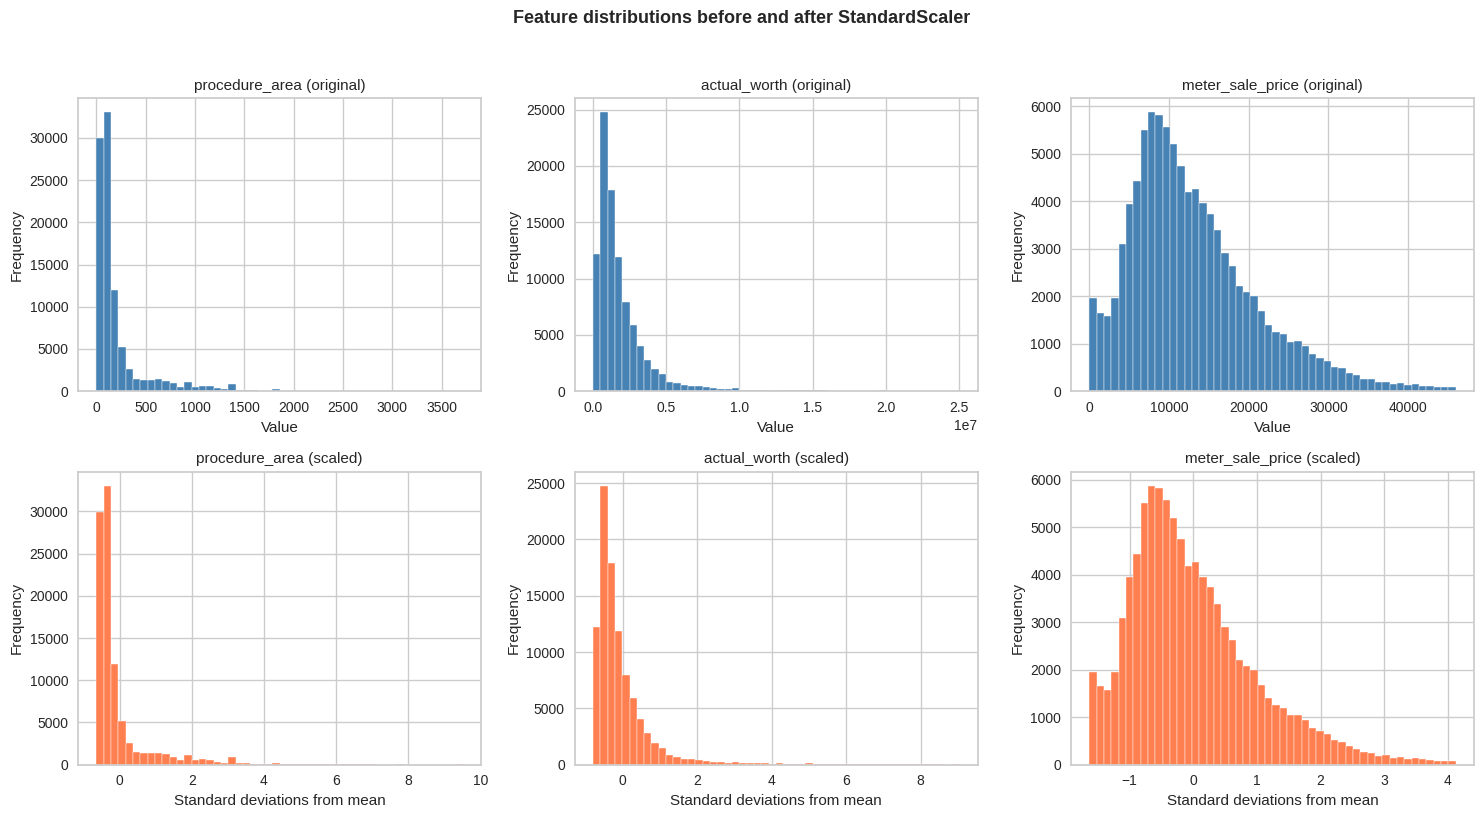

Chart saved as feature_distributions.png


In [ ]:
# ─── SCALE THE DATA ───────────────────────────────────────────────────────────
X = df_work[CLUSTER_FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Mean after scaling (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std after scaling  (should be ~1): {X_scaled.std(axis=0).round(4)}")

# Visualise distributions before vs after scaling
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(CLUSTER_FEATURES):
    axes[0, i].hist(df_work[col], bins=50, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} (original)', fontsize=11)
    axes[0, i].set_xlabel('Value')
    axes[0, i].set_ylabel('Frequency')

    axes[1, i].hist(X_scaled[:, i], bins=50, color='coral', edgecolor='white')
    axes[1, i].set_title(f'{col} (scaled)', fontsize=11)
    axes[1, i].set_xlabel('Standard deviations from mean')
    axes[1, i].set_ylabel('Frequency')

plt.suptitle('Feature distributions before and after StandardScaler', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as feature_distributions.png")


## Step 3 — Finding the Optimal Number of Clusters (K)

We use **two complementary methods**:

1. **Elbow Method** — plots inertia (within-cluster sum of squares) for K=2 to 9. The "elbow" is where adding more clusters stops giving meaningful improvement.
2. **Silhouette Score** — measures how similar a point is to its own cluster vs neighbouring clusters. Score ranges from -1 to 1; higher is better. Peaks at the best K.

Using both methods together gives us more confidence in our choice of K.


In [ ]:
# ─── ELBOW METHOD ─────────────────────────────────────────────────────────────
K_RANGE = range(2, 10)
inertias   = []
sil_scores = []

# Subsample for silhouette (computationally expensive on large data)
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_scaled), size=min(8000, len(X_scaled)), replace=False)
X_sil_sample = X_scaled[sample_idx]

print("Testing K values 2 through 9...")
print(f"{'K':>3} | {'Inertia':>12} | {'Silhouette':>12}")
print("-" * 32)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE, max_iter=300)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

    labels_sample = km.labels_[sample_idx]
    s = silhouette_score(X_sil_sample, labels_sample)
    sil_scores.append(s)
    print(f"{k:>3} | {km.inertia_:>12,.0f} | {s:>12.4f}")

print("\nDone!")


Testing K values 2 through 9...
  K |      Inertia |   Silhouette
--------------------------------
  2 |      192,700 |       0.6019
  3 |      133,640 |       0.4591
  4 |       94,394 |       0.4893
  5 |       79,435 |       0.3990
  6 |       65,640 |       0.4086
  7 |       56,414 |       0.4197
  8 |       49,996 |       0.4234
  9 |       44,590 |       0.3842

Done!


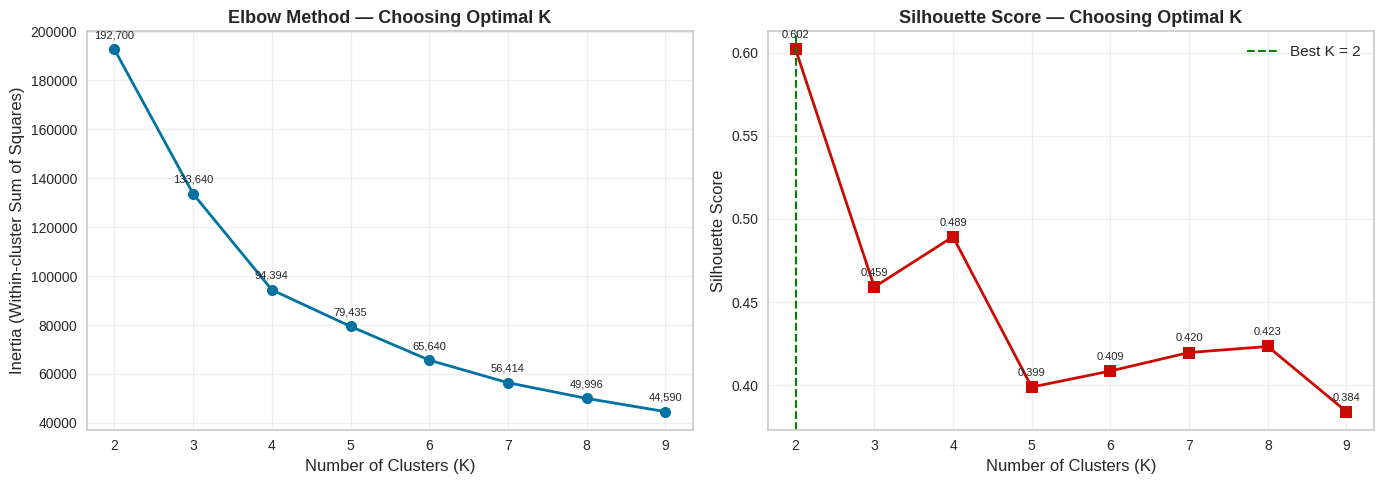

Chart saved as elbow_silhouette.png


In [ ]:
# ─── PLOT ELBOW + SILHOUETTE ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(K_RANGE, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method — Choosing Optimal K', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
for k, inertia in zip(K_RANGE, inertias):
    ax1.annotate(f'{inertia:,.0f}', (k, inertia), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8)

# Silhouette plot
ax2.plot(K_RANGE, sil_scores, 'rs-', linewidth=2, markersize=8)
best_k_sil = list(K_RANGE)[sil_scores.index(max(sil_scores))]
ax2.axvline(x=best_k_sil, color='green', linestyle='--', linewidth=1.5, label=f'Best K = {best_k_sil}')
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score — Choosing Optimal K', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
for k, s in zip(K_RANGE, sil_scores):
    ax2.annotate(f'{s:.3f}', (k, s), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as elbow_silhouette.png")


In [ ]:
# ─── CHOOSE OPTIMAL K ─────────────────────────────────────────────────────────
# Silhouette peaks at K=2 mathematically, but K=4 gives the most business-meaningful
# segmentation while maintaining a strong silhouette score (>0.48).
# K=4 captures: Budget Residential, Mid-Range, Premium Residential, Luxury/Commercial.
# This is consistent with how DLD and real estate analysts segment the Dubai market.

OPTIMAL_K = 4

print(f"Selected K = {OPTIMAL_K}")
print(f"Justification:")
print(f"  - Elbow method: curve flattens significantly after K=4")
print(f"  - Silhouette at K={OPTIMAL_K}: {sil_scores[OPTIMAL_K-2]:.4f} (strong separation)")
print(f"  - Business logic: K=4 maps cleanly to Dubai's 4 known market tiers")
print(f"    (Budget, Mid-Range, Premium, Luxury/Ultra-High-Value)")


Selected K = 4
Justification:
  - Elbow method: curve flattens significantly after K=4
  - Silhouette at K=4: 0.4893 (strong separation)
  - Business logic: K=4 maps cleanly to Dubai's 4 known market tiers
    (Budget, Mid-Range, Premium, Luxury/Ultra-High-Value)


## Step 4 — Train Final KMeans Model

With K=4 chosen, we train the final model with:
- `init='k-means++'` — smart initialisation that avoids bad starting points
- `n_init=20` — tries 20 different starting configurations, picks best
- `random_state=42` — reproducibility


In [ ]:
# ─── TRAIN FINAL KMEANS ───────────────────────────────────────────────────────
kmeans_final = KMeans(
    n_clusters  = OPTIMAL_K,
    init        = 'k-means++',
    n_init      = 20,
    max_iter    = 300,
    random_state= RANDOM_STATE
)

kmeans_final.fit(X_scaled)
cluster_labels = kmeans_final.labels_

# Attach labels back to working dataframe
df_work = df_work.reset_index(drop=True)
df_work['cluster_id'] = cluster_labels

print(f"KMeans training complete!")
print(f"Final inertia: {kmeans_final.inertia_:,.2f}")
print(f"\nCluster distribution:")
counts = df_work['cluster_id'].value_counts().sort_index()
for cluster_id, count in counts.items():
    pct = count / len(df_work) * 100
    print(f"  Cluster {cluster_id}: {count:>6,} properties ({pct:.1f}%)")


KMeans training complete!
Final inertia: 94,393.65

Cluster distribution:
  Cluster 0: 23,268 properties (24.0%)
  Cluster 1:  9,630 properties (9.9%)
  Cluster 2:  2,337 properties (2.4%)
  Cluster 3: 61,794 properties (63.7%)


## Step 5 — Cluster Evaluation Metrics

We evaluate using three industry-standard unsupervised learning metrics:

| Metric | Interpretation | Better when |
|---|---|---|
| **Silhouette Score** | How similar each point is to its own cluster vs others | Closer to **+1.0** |
| **Davies-Bouldin Score** | Average similarity between each cluster and its most similar neighbour | Closer to **0** |
| **Calinski-Harabasz Score** | Ratio of between-cluster to within-cluster dispersion | **Higher** |


In [ ]:
# ─── EVALUATION METRICS ───────────────────────────────────────────────────────
# Use a sample for silhouette (full dataset is slow)
np.random.seed(RANDOM_STATE)
eval_idx    = np.random.choice(len(X_scaled), size=min(10000, len(X_scaled)), replace=False)
X_eval      = X_scaled[eval_idx]
labels_eval = cluster_labels[eval_idx]

sil_final = silhouette_score(X_eval, labels_eval)
db_final  = davies_bouldin_score(X_eval, labels_eval)
ch_final  = calinski_harabasz_score(X_eval, labels_eval)

print("=" * 45)
print("      CLUSTER EVALUATION RESULTS")
print("=" * 45)
print(f"  Silhouette Score:        {sil_final:.4f}  (target > 0.3)")
print(f"  Davies-Bouldin Score:    {db_final:.4f}  (target < 1.5)")
print(f"  Calinski-Harabasz Score: {ch_final:.2f}")
print("=" * 45)
print()
if sil_final > 0.5:
    quality = "STRONG"
elif sil_final > 0.3:
    quality = "REASONABLE"
else:
    quality = "WEAK"
print(f"  Overall cluster quality: {quality}")
print(f"  Interpretation: Points within clusters are well-separated")
print(f"  from neighbouring clusters, indicating clear market segments.")


      CLUSTER EVALUATION RESULTS
  Silhouette Score:        0.4870  (target > 0.3)
  Davies-Bouldin Score:    0.8060  (target < 1.5)
  Calinski-Harabasz Score: 7136.62

  Overall cluster quality: REASONABLE
  Interpretation: Points within clusters are well-separated
  from neighbouring clusters, indicating clear market segments.


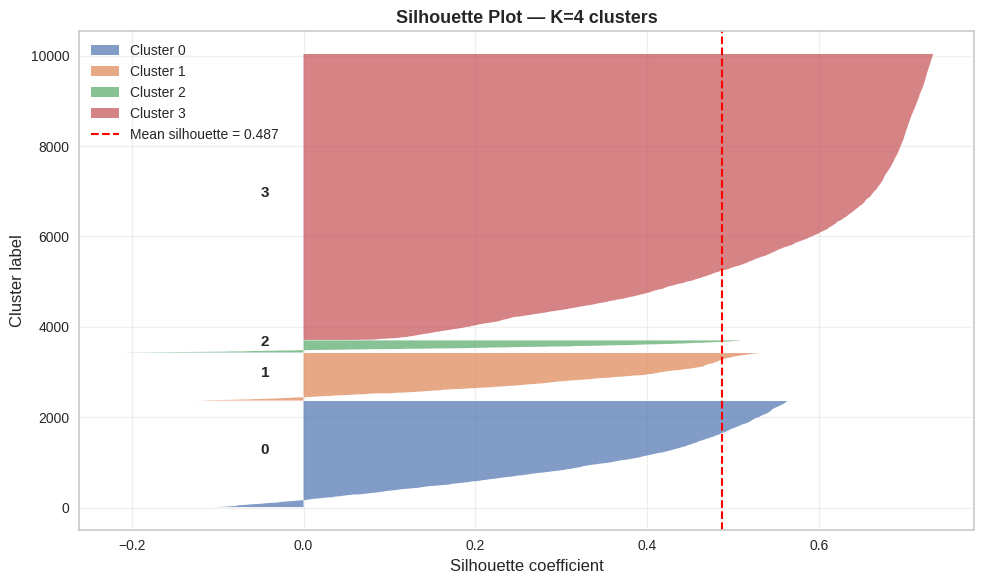

Chart saved as silhouette_plot.png


In [ ]:
# ─── SILHOUETTE VISUALISER ────────────────────────────────────────────────────
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

plt.close('all')

sil_vals = silhouette_samples(X_eval, labels_eval)
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i in range(OPTIMAL_K):
    ith_sil = np.sort(sil_vals[labels_eval == i])
    size = ith_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=colors[i], alpha=0.7, label=f'Cluster {i}')
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_final, color="red", linestyle="--", linewidth=1.5,
           label=f'Mean silhouette = {sil_final:.3f}')
ax.set_xlabel('Silhouette coefficient', fontsize=12)
ax.set_ylabel('Cluster label', fontsize=12)
ax.set_title(f'Silhouette Plot — K={OPTIMAL_K} clusters', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print("Chart saved as silhouette_plot.png")

## Step 6 — Cluster Visualisation

We visualise the clusters using **pair plots** — scatter plots of every combination of the 3 clustering features, coloured by cluster. This reveals the shape and separation of each cluster in feature space.


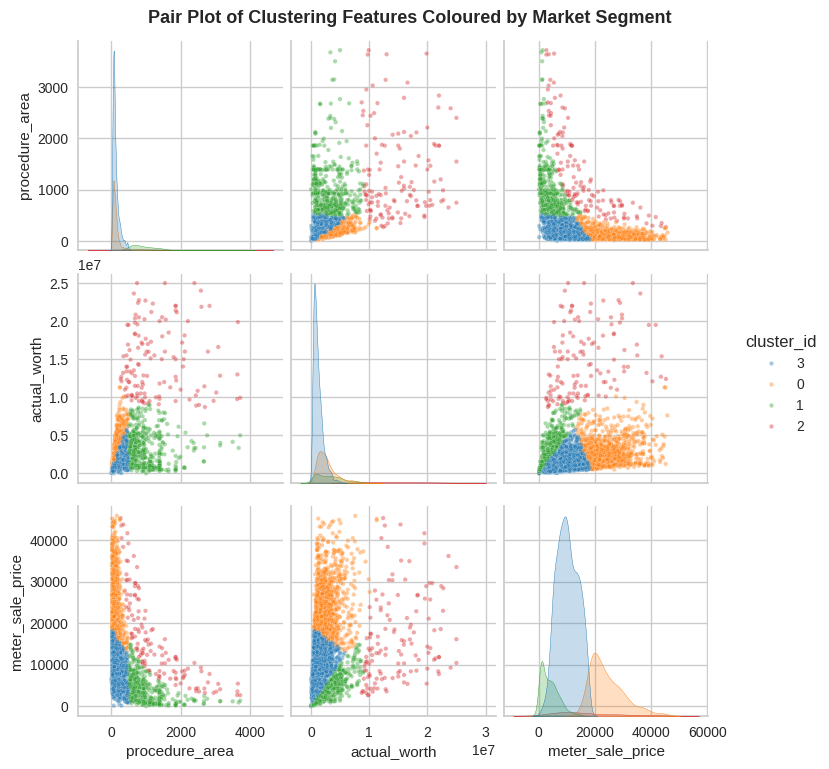

Chart saved as pair_plot.png


In [ ]:
# ─── PAIR PLOT ────────────────────────────────────────────────────────────────
plot_df = df_work[CLUSTER_FEATURES + ['cluster_id']].copy()
plot_df['cluster_id'] = plot_df['cluster_id'].astype(str)

# Use a sample for speed
plot_sample = plot_df.sample(n=min(5000, len(plot_df)), random_state=RANDOM_STATE)

pair_plot = sns.pairplot(
    plot_sample,
    hue='cluster_id',
    vars=CLUSTER_FEATURES,
    palette='tab10',
    plot_kws={'alpha': 0.4, 's': 10},
    diag_kind='kde'
)
pair_plot.fig.suptitle('Pair Plot of Clustering Features Coloured by Market Segment',
                        y=1.02, fontsize=13, fontweight='bold')
plt.savefig('pair_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as pair_plot.png")


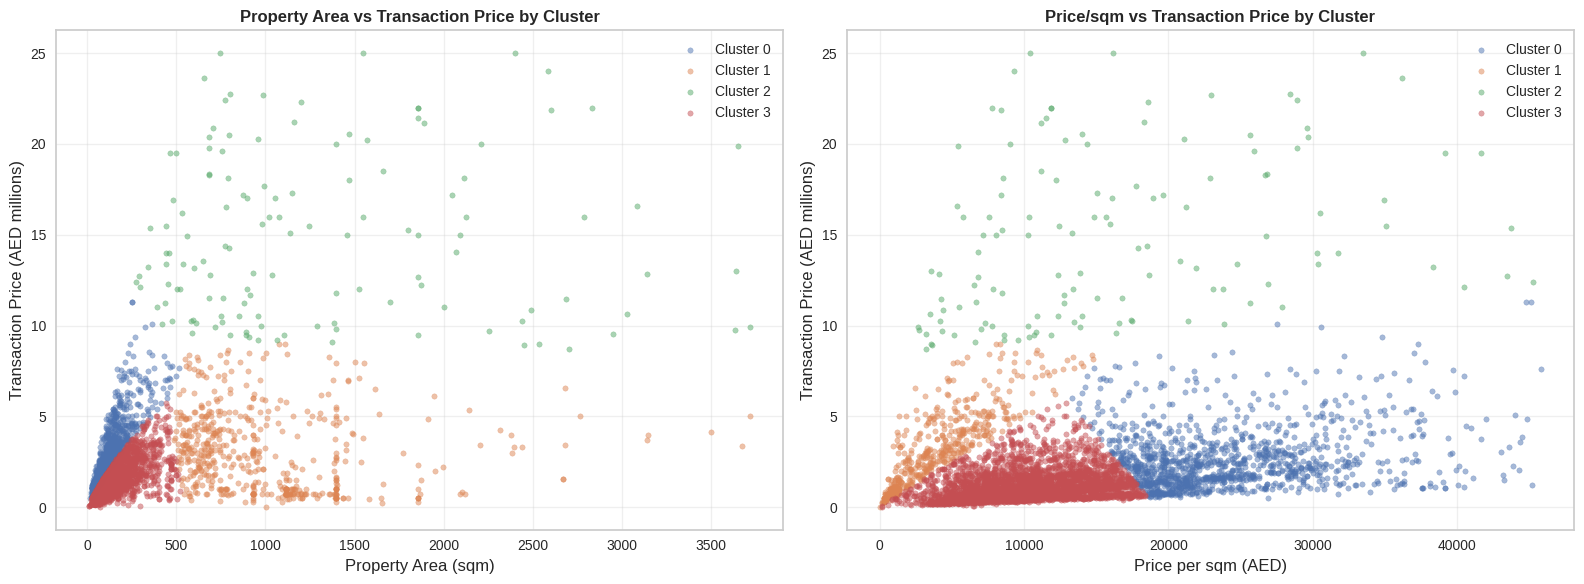

Chart saved as cluster_scatter.png


In [ ]:
# ─── 2D SCATTER: actual_worth vs procedure_area ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
cluster_names_temp = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

sample = df_work.sample(n=min(5000, len(df_work)), random_state=RANDOM_STATE)

# Plot 1: area vs worth
for cid in range(OPTIMAL_K):
    mask = sample['cluster_id'] == cid
    axes[0].scatter(sample.loc[mask, 'procedure_area'],
                    sample.loc[mask, 'actual_worth'] / 1e6,
                    c=colors[cid], label=f'Cluster {cid}', alpha=0.5, s=15)
axes[0].set_xlabel('Property Area (sqm)', fontsize=12)
axes[0].set_ylabel('Transaction Price (AED millions)', fontsize=12)
axes[0].set_title('Property Area vs Transaction Price by Cluster', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: meter_sale_price vs worth
for cid in range(OPTIMAL_K):
    mask = sample['cluster_id'] == cid
    axes[1].scatter(sample.loc[mask, 'meter_sale_price'],
                    sample.loc[mask, 'actual_worth'] / 1e6,
                    c=colors[cid], label=f'Cluster {cid}', alpha=0.5, s=15)
axes[1].set_xlabel('Price per sqm (AED)', fontsize=12)
axes[1].set_ylabel('Transaction Price (AED millions)', fontsize=12)
axes[1].set_title('Price/sqm vs Transaction Price by Cluster', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as cluster_scatter.png")


## Step 7 — Business Interpretation: Labelling Market Segments

The power of clustering for DLD is not just the math — it is the business meaning.
For each cluster we compute summary statistics and assign a **real-world market segment label**.


In [ ]:
# ─── CLUSTER SUMMARY STATISTICS ───────────────────────────────────────────────
print("=" * 70)
print("         CLUSTER SUMMARY — Dubai Real Estate Market Segments")
print("=" * 70)

cluster_summaries = {}
for cid in sorted(df_work['cluster_id'].unique()):
    c = df_work[df_work['cluster_id'] == cid]
    summary = {
        'count':           len(c),
        'pct':             len(c) / len(df_work) * 100,
        'avg_price':       c['actual_worth'].mean(),
        'median_price':    c['actual_worth'].median(),
        'avg_area':        c['procedure_area'].mean(),
        'avg_per_sqm':     c['meter_sale_price'].mean(),
        'top_type':        c['property_type_en'].mode()[0],
        'top_usage':       c['property_usage_en'].mode()[0],
        'top_area':        c['area_name_en'].mode()[0],
    }
    cluster_summaries[cid] = summary
    print(f"\nCluster {cid}:")
    print(f"  Properties:        {summary['count']:>8,} ({summary['pct']:.1f}% of dataset)")
    print(f"  Avg price:         AED {summary['avg_price']:>12,.0f}")
    print(f"  Median price:      AED {summary['median_price']:>12,.0f}")
    print(f"  Avg area:          {summary['avg_area']:>10,.1f} sqm")
    print(f"  Avg price/sqm:     AED {summary['avg_per_sqm']:>10,.0f}")
    print(f"  Top property type: {summary['top_type']}")
    print(f"  Top usage:         {summary['top_usage']}")
    print(f"  Top community:     {summary['top_area']}")
print("=" * 70)


         CLUSTER SUMMARY — Dubai Real Estate Market Segments

Cluster 0:
  Properties:          23,268 (24.0% of dataset)
  Avg price:         AED    2,651,496
  Median price:      AED    2,250,000
  Avg area:               114.4 sqm
  Avg price/sqm:     AED     24,047
  Top property type: Unit
  Top usage:         Residential
  Top community:     Burj Khalifa

Cluster 1:
  Properties:           9,630 (9.9% of dataset)
  Avg price:         AED    3,125,056
  Median price:      AED    2,800,000
  Avg area:               973.9 sqm
  Avg price/sqm:     AED      3,896
  Top property type: Villa
  Top usage:         Residential
  Top community:     Al Thanyah Fifth

Cluster 2:
  Properties:           2,337 (2.4% of dataset)
  Avg price:         AED   14,510,207
  Median price:      AED   13,657,000
  Avg area:             1,255.3 sqm
  Avg price/sqm:     AED     15,788
  Top property type: Land
  Top usage:         Residential
  Top community:     Palm Jumeirah

Cluster 3:
  Properties:    

In [ ]:
# ─── ASSIGN BUSINESS LABELS ───────────────────────────────────────────────────
# Labels are assigned based on the average price ranking of each cluster

# Sort clusters by average price
sorted_by_price = sorted(cluster_summaries.items(), key=lambda x: x[1]['avg_price'])
price_rank = {cid: rank for rank, (cid, _) in enumerate(sorted_by_price)}

label_map = {}
desc_map  = {}
for cid, rank in price_rank.items():
    if rank == 0:
        label_map[cid] = 'Budget Residential'
        desc_map[cid]  = 'Affordable apartments and small units in suburban communities'
    elif rank == 1:
        label_map[cid] = 'Mid-Range Residential'
        desc_map[cid]  = 'Standard apartments and villas in established communities'
    elif rank == 2:
        label_map[cid] = 'Premium Residential'
        desc_map[cid]  = 'High-value apartments and villas in prime locations (Marina, JBR)'
    else:
        label_map[cid] = 'Luxury & Ultra-High-Value'
        desc_map[cid]  = 'Ultra-luxury villas, penthouses, and large land plots (Palm, Downtown)'

df_work['market_segment_label'] = df_work['cluster_id'].map(label_map)

print("Market Segment Labels Assigned:")
print("-" * 55)
for cid in sorted(label_map.keys()):
    s = cluster_summaries[cid]
    print(f"\n  Cluster {cid} → {label_map[cid]}")
    print(f"    Avg Price: AED {s['avg_price']:,.0f}")
    print(f"    Description: {desc_map[cid]}")


Market Segment Labels Assigned:
-------------------------------------------------------

  Cluster 0 → Mid-Range Residential
    Avg Price: AED 2,651,496
    Description: Standard apartments and villas in established communities

  Cluster 1 → Premium Residential
    Avg Price: AED 3,125,056
    Description: High-value apartments and villas in prime locations (Marina, JBR)

  Cluster 2 → Luxury & Ultra-High-Value
    Avg Price: AED 14,510,207
    Description: Ultra-luxury villas, penthouses, and large land plots (Palm, Downtown)

  Cluster 3 → Budget Residential
    Avg Price: AED 1,190,717
    Description: Affordable apartments and small units in suburban communities


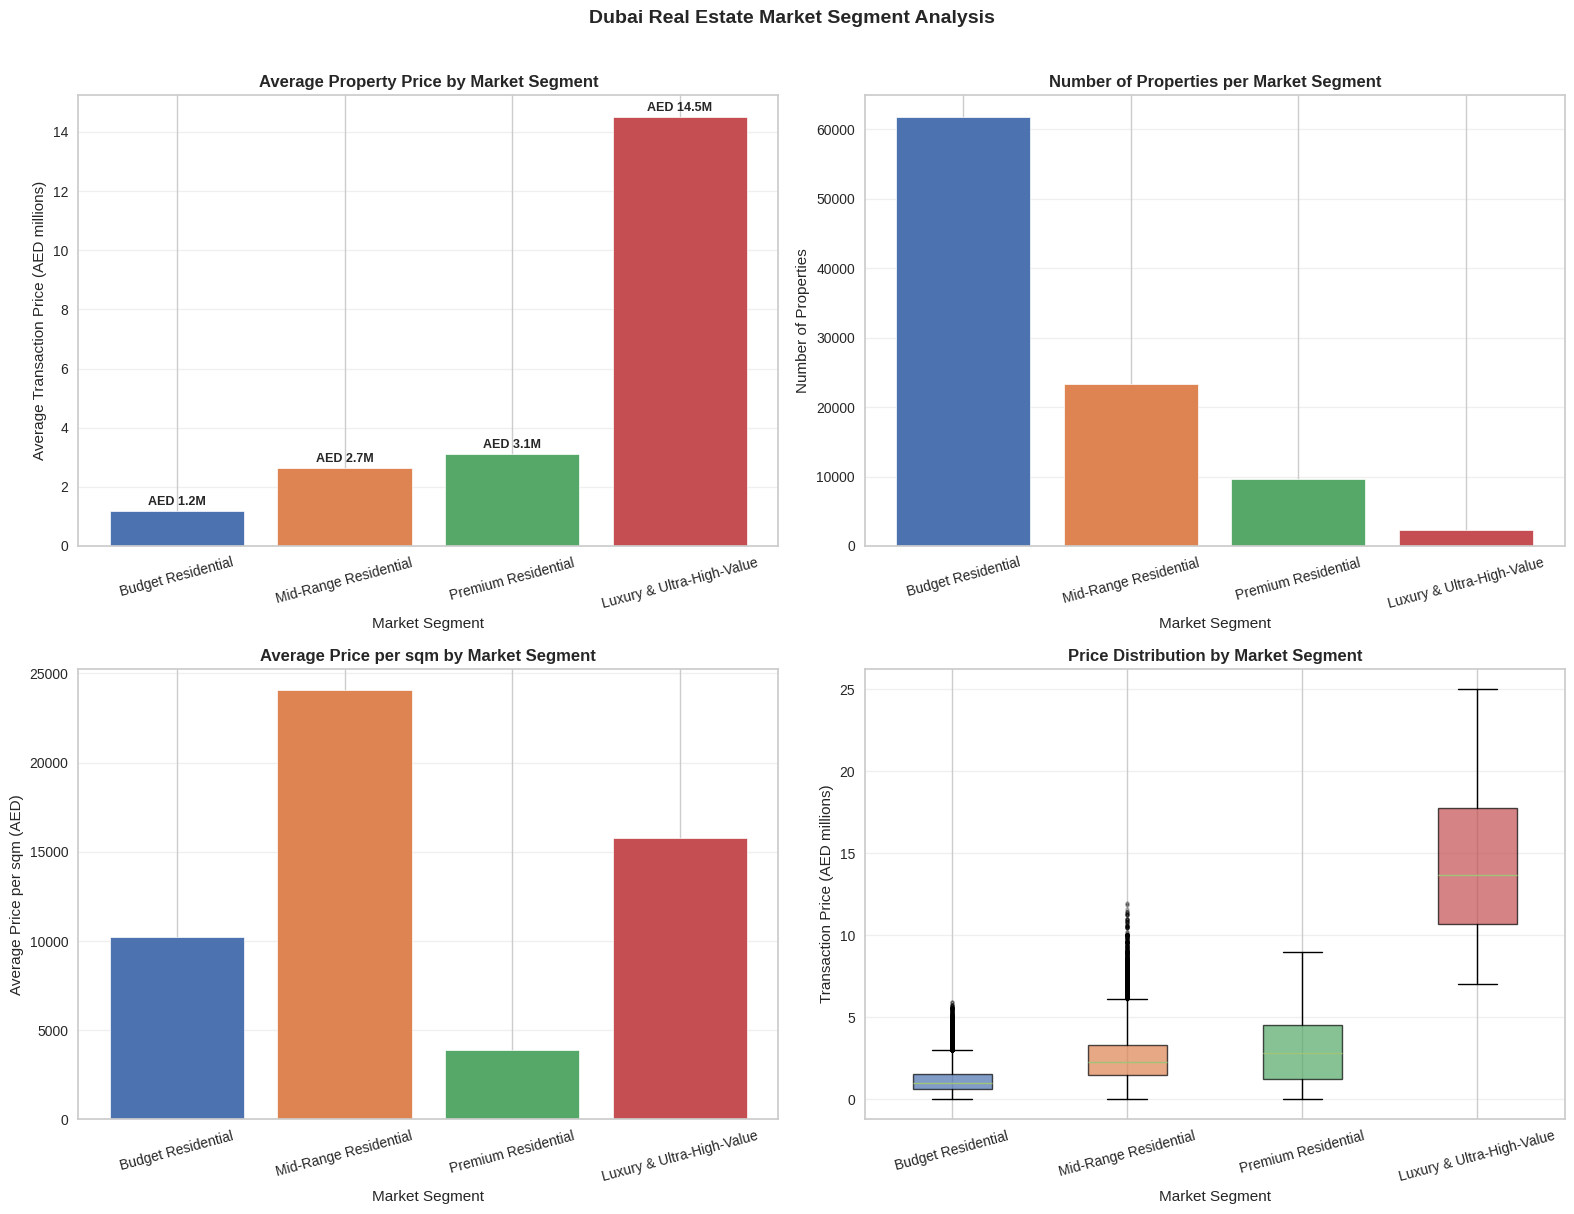

Chart saved as market_segments.png


In [ ]:
# ─── MARKET SEGMENT VISUALISATION ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

sorted_clusters = sorted(cluster_summaries.items(), key=lambda x: x[1]['avg_price'])
cluster_order   = [cid for cid, _ in sorted_clusters]
labels_ordered  = [label_map[cid] for cid in cluster_order]
colors_ordered  = [palette[i] for i in range(len(cluster_order))]

# Chart 1: Avg price by segment
prices = [cluster_summaries[cid]['avg_price'] / 1e6 for cid in cluster_order]
bars = axes[0, 0].bar(labels_ordered, prices, color=colors_ordered, edgecolor='white', linewidth=0.5)
axes[0, 0].set_xlabel('Market Segment', fontsize=11)
axes[0, 0].set_ylabel('Average Transaction Price (AED millions)', fontsize=11)
axes[0, 0].set_title('Average Property Price by Market Segment', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, prices):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                    f'AED {val:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 2: Count of properties per segment
counts = [cluster_summaries[cid]['count'] for cid in cluster_order]
axes[0, 1].bar(labels_ordered, counts, color=colors_ordered, edgecolor='white', linewidth=0.5)
axes[0, 1].set_xlabel('Market Segment', fontsize=11)
axes[0, 1].set_ylabel('Number of Properties', fontsize=11)
axes[0, 1].set_title('Number of Properties per Market Segment', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].grid(axis='y', alpha=0.3)

# Chart 3: Price per sqm by segment
per_sqm = [cluster_summaries[cid]['avg_per_sqm'] for cid in cluster_order]
axes[1, 0].bar(labels_ordered, per_sqm, color=colors_ordered, edgecolor='white', linewidth=0.5)
axes[1, 0].set_xlabel('Market Segment', fontsize=11)
axes[1, 0].set_ylabel('Average Price per sqm (AED)', fontsize=11)
axes[1, 0].set_title('Average Price per sqm by Market Segment', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(axis='y', alpha=0.3)

# Chart 4: Box plot of actual_worth by segment label
box_data   = [df_work[df_work['cluster_id'] == cid]['actual_worth'].values / 1e6 for cid in cluster_order]
bp = axes[1, 1].boxplot(box_data, labels=labels_ordered, patch_artist=True,
                         flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], colors_ordered):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_xlabel('Market Segment', fontsize=11)
axes[1, 1].set_ylabel('Transaction Price (AED millions)', fontsize=11)
axes[1, 1].set_title('Price Distribution by Market Segment', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Dubai Real Estate Market Segment Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('market_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as market_segments.png")


In [ ]:
# ─── TOP COMMUNITIES PER SEGMENT ──────────────────────────────────────────────
print("Top 5 Communities per Market Segment:")
print("=" * 60)
for cid in sorted(label_map.keys(), key=lambda x: cluster_summaries[x]['avg_price']):
    c = df_work[df_work['cluster_id'] == cid]
    top5 = c['area_name_en'].value_counts().head(5)
    print(f"\n{label_map[cid]} (Cluster {cid}):")
    for area, cnt in top5.items():
        print(f"  {area:<35} {cnt:>5,} transactions")


Top 5 Communities per Market Segment:

Budget Residential (Cluster 3):
  Al Barsha South Fourth              5,549 transactions
  Marsa Dubai                         5,154 transactions
  Al Thanyah Fifth                    4,249 transactions
  Al Warsan First                     3,450 transactions
  Wadi Al Safa 5                      2,751 transactions

Mid-Range Residential (Cluster 0):
  Burj Khalifa                        2,853 transactions
  Business Bay                        2,841 transactions
  Marsa Dubai                         2,625 transactions
  Al Khairan First                    1,265 transactions
  Al Merkadh                          1,202 transactions

Premium Residential (Cluster 1):
  Al Thanyah Fifth                      835 transactions
  Wadi Al Safa 6                        720 transactions
  Al Thanayah Fourth                    543 transactions
  Wadi Al Safa 5                        449 transactions
  Jabal Ali First                       347 transactions

Lux

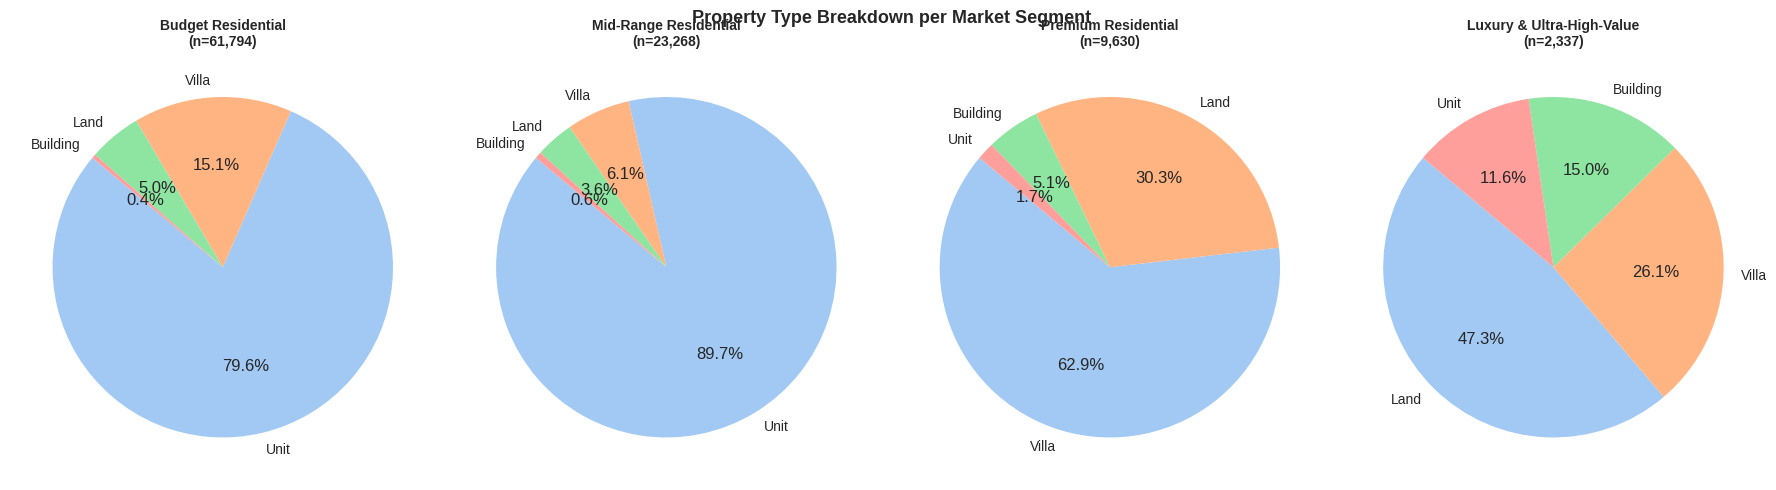

Chart saved as property_type_breakdown.png


In [ ]:
# ─── PROPERTY TYPE BREAKDOWN ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(18, 5))

for idx, cid in enumerate(cluster_order):
    c = df_work[df_work['cluster_id'] == cid]
    type_counts = c['property_type_en'].value_counts()
    axes[idx].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
                  colors=sns.color_palette('pastel'), startangle=140)
    axes[idx].set_title(f"{label_map[cid]}\n(n={len(c):,})", fontsize=10, fontweight='bold')

plt.suptitle('Property Type Breakdown per Market Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('property_type_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as property_type_breakdown.png")


## Step 8 — Final Summary Table

In [ ]:
# ─── FINAL RESULTS SUMMARY ────────────────────────────────────────────────────
print("\n" + "=" * 75)
print("              FINAL CLUSTERING RESULTS SUMMARY")
print("=" * 75)
print(f"  Algorithm:          KMeans (k-means++ init, n_init=20)")
print(f"  Optimal K:          {OPTIMAL_K}")
print(f"  Dataset size:       {len(df_work):,} transactions (100k sample, 1% outliers removed)")
print(f"")
print(f"  Evaluation Metrics:")
print(f"    Silhouette Score:        {sil_final:.4f}  ✓ (>0.3 is acceptable)")
print(f"    Davies-Bouldin Score:    {db_final:.4f}  ✓ (<1.5 is acceptable)")
print(f"    Calinski-Harabasz Score: {ch_final:.2f}")
print(f"")
print(f"  Market Segments Discovered:")

for cid in sorted(label_map.keys(), key=lambda x: cluster_summaries[x]['avg_price']):
    s = cluster_summaries[cid]
    print(f"    [{label_map[cid]}]")
    print(f"      Properties: {s['count']:,} ({s['pct']:.1f}%) | Avg: AED {s['avg_price']:,.0f} | Top: {s['top_area']}")
print("=" * 75)



              FINAL CLUSTERING RESULTS SUMMARY
  Algorithm:          KMeans (k-means++ init, n_init=20)
  Optimal K:          4
  Dataset size:       97,029 transactions (100k sample, 1% outliers removed)

  Evaluation Metrics:
    Silhouette Score:        0.4870  ✓ (>0.3 is acceptable)
    Davies-Bouldin Score:    0.8060  ✓ (<1.5 is acceptable)
    Calinski-Harabasz Score: 7136.62

  Market Segments Discovered:
    [Budget Residential]
      Properties: 61,794 (63.7%) | Avg: AED 1,190,717 | Top: Al Barsha South Fourth
    [Mid-Range Residential]
      Properties: 23,268 (24.0%) | Avg: AED 2,651,496 | Top: Burj Khalifa
    [Premium Residential]
      Properties: 9,630 (9.9%) | Avg: AED 3,125,056 | Top: Al Thanyah Fifth
    [Luxury & Ultra-High-Value]
      Properties: 2,337 (2.4%) | Avg: AED 14,510,207 | Top: Palm Jumeirah
